# Paris Airbnb Fiyat Tahmini

Bu projede Paris'teki Airbnb ilanlarının gecelik fiyatlarını etkileyen faktörler incelenmiş ve farklı regresyon modellerinin tahmin performansları karşılaştırılmıştır.

Çalışma; veri inceleme ve temizleme, keşifsel veri analizi, aykırı değer analizi, özellik hazırlama, modelleme, hiperparametre optimizasyonu ve model değerlendirme adımlarından oluşmaktadır. Model performansı yalnızca test skoru ile değil, eğitim–test farkı ve çapraz doğrulama sonuçlarıyla birlikte değerlendirilmiştir.

## 1. Kütüphaneler ve Tekrar Üretilebilirlik

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

SEED = 42
np.random.seed(SEED)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 110

print("Kütüphaneler hazır.")

Kütüphaneler hazır.


## 2. Veri Yükleme

Veri kaynağı Inside Airbnb'nin Paris için 16 Haziran 2026 tarihli detaylı `listings.csv.gz` dosyasıdır.
Kod önce aynı klasörde yerel dosyayı arar; yoksa kaynaktan indirmeyi dener.

In [ ]:
from pathlib import Path

local_candidates = [
    Path("listings_paris_2026-06-16.csv.gz"),
    Path("listings.csv.gz"),
]
url = "https://data.insideairbnb.com/france/ile-de-france/paris/2026-06-16/data/listings.csv.gz"

local_file = next((p for p in local_candidates if p.exists()), None)
if local_file is not None:
    df = pd.read_csv(local_file, compression="gzip", low_memory=False)
    print(f"Yerel veri yüklendi: {local_file}")
else:
    df = pd.read_csv(url, compression="gzip", low_memory=False)
    print("Veri Inside Airbnb adresinden yüklendi.")

print("Ham veri boyutu:", df.shape)
df.head()

Veri Inside Airbnb adresinden yüklendi.
Ham veri boyutu: (77679, 90)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,114543,https://www.airbnb.com/rooms/114543,20260616211535,2026-06-21,city scrape,Charming 55m² flat - Eiffel Tower,Fully furnished charming flat with lots of spa...,NaN,https://a0.muscache.com/pictures/airflow/Hosti...,581233,...,4.97,4.93,4.77,7511502831082,NaN,1,1,0,0,0.83
1,115107,https://www.airbnb.com/rooms/115107,20260616211535,2026-06-25,previous scrape,Charming two-bed apartment with balcony,This charming 60 square meter apartment is per...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,379042,...,5.00,4.40,4.40,7511002008206,NaN,2,1,1,0,0.22
2,115655,https://www.airbnb.com/rooms/115655,20260616211535,2026-06-20,city scrape,Family loft with a private courtyard,"Beautiful openplan loft situated in a private,...",NaN,https://a0.muscache.com/pictures/33160696/6171...,584977,...,4.69,4.04,4.40,7511805457226,NaN,1,1,0,0,1.24
3,120494,https://www.airbnb.com/rooms/120494,20260616211535,2026-06-19,city scrape,Romantic Hideout in Paris,"""As full of spirit as the month of May, as gor...",NaN,https://a0.muscache.com/pictures/833324/f66a6b...,606427,...,4.97,4.85,4.75,7511300905786,NaN,1,1,0,0,2.03
4,125686,https://www.airbnb.com/rooms/125686,20260616211535,2026-06-20,city scrape,Studio - République/Canal Saint Martin,"Tiny studio in central Paris, between the Mara...",NaN,https://a0.muscache.com/pictures/2704337/e28df...,624523,...,4.92,4.87,4.69,"Available with a mobility lease only (""bail mo...",NaN,1,1,0,0,0.79


## 3. İlk İnceleme

In [ ]:
print("Boyut:", df.shape)
print("Tekrarlı satır sayısı:", df.duplicated().sum())
print("Sütun sayısı:", len(df.columns))
df.info()

Boyut: (77679, 90)
Tekrarlı satır sayısı: 0
Sütun sayısı: 90
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77679 entries, 0 to 77678
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            77679 non-null  int64  
 1   listing_url                                   77679 non-null  object 
 2   scrape_id                                     77679 non-null  int64  
 3   last_scraped                                  77679 non-null  object 
 4   source                                        77679 non-null  object 
 5   name                                          77679 non-null  object 
 6   description                                   74850 non-null  object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   77678 non-null  object 
 9   

## 4. Değişken Seçimi ve Temel Temizlik

Modelde doğrudan fiyatla ilişkili olduğu düşünülen, yorumlanabilir ve proje kapsamına uygun değişkenler seçilir. `property_type` çok yüksek kardinalite oluşturduğu için ana modelden çıkarılır; `room_type` daha sade bir konaklama türü bilgisi sağlar.

In [ ]:
kolonlar = [
    "id", "neighbourhood_cleansed", "latitude", "longitude",
    "room_type", "property_type", "accommodates",
    "bedrooms", "bathrooms", "beds", "price",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "minimum_nights", "availability_365"
]

df_secili = df[kolonlar].copy()

df_secili["price"] = pd.to_numeric(
    df_secili["price"].astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False),
    errors="coerce"
)

# Hedef fiyatı olmayan kayıtlar modelleme için kullanılamaz.
df_secili = df_secili.dropna(subset=["price"]).copy()
# Negatif/sıfır fiyat modelin hedefi açısından anlamlı değildir.
df_secili = df_secili[df_secili["price"] > 0].copy()

df_secili = df_secili.rename(columns={"price": "price_eur"})
print("Fiyat temizliği sonrası boyut:", df_secili.shape)
df_secili["price_eur"].describe()

Fiyat temizliği sonrası boyut: (48402, 16)


,price_eur
count,48402.000000
mean,321.230271
std,832.551387
min,3.200000
25%,131.330000
50%,205.500000
75%,342.000000
max,97003.050000


## 5. Eksik Veri Analizi

In [ ]:
eksik = pd.DataFrame({
    "Eksik Sayısı": df_secili.isnull().sum(),
    "Eksik %": (df_secili.isnull().mean() * 100).round(2)
}).sort_values("Eksik %", ascending=False)

eksik[eksik["Eksik Sayısı"] > 0]

,Eksik Sayısı,Eksik %
reviews_per_month,8342,17.23
review_scores_rating,8342,17.23
bedrooms,7757,16.03
bathrooms,5853,12.09
beds,4366,9.02


## 6. Kapsamlı Outlier Analizi — IQR

Ders notlarındaki IQR yaklaşımı tüm anlamlı sayısal değişkenlere uygulanır. Burada amaç önce **tespit etmek** ve hangi sütunlarda problemin yoğun olduğunu görmek; her outlier'ı otomatik olarak silmek değildir.

In [ ]:
outlier_kolonlari = [
    "price_eur", "accommodates", "bedrooms", "bathrooms", "beds",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "minimum_nights", "availability_365"
]

def iqr_ozeti(data, columns):
    rows = []
    for col in columns:
        s = data[col].dropna()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (s < lower) | (s > upper)
        rows.append({
            "Değişken": col,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Alt Sınır": lower,
            "Üst Sınır": upper,
            "Outlier Sayısı": int(mask.sum()),
            "Outlier %": round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows).sort_values("Outlier %", ascending=False)

outlier_ozet = iqr_ozeti(df_secili, outlier_kolonlari)
outlier_ozet.round(2)

,Değişken,Q1,Q3,IQR,Alt Sınır,Üst Sınır,Outlier Sayısı,Outlier %
3,bathrooms,1.00,1.00,0.00,1.00,1.00,9496,22.32
8,minimum_nights,1.00,4.00,3.00,-3.50,8.50,7345,15.17
4,beds,1.00,2.00,1.00,-0.50,3.50,4098,9.31
5,number_of_reviews,2.00,45.00,43.00,-62.50,109.50,4355,9.00
0,price_eur,131.33,342.00,210.67,-184.68,658.00,3799,7.85
6,reviews_per_month,0.33,1.87,1.54,-1.98,4.18,2261,5.64
7,review_scores_rating,4.67,4.98,0.31,4.20,5.45,2227,5.56
1,accommodates,2.00,4.00,2.00,-1.00,7.00,1821,3.76
2,bedrooms,1.00,2.00,1.00,-0.50,3.50,1229,3.02
9,availability_365,79.00,305.00,226.00,-260.00,644.00,0,0.00


### 6.1 Boxplot ile Görsel Kontrol

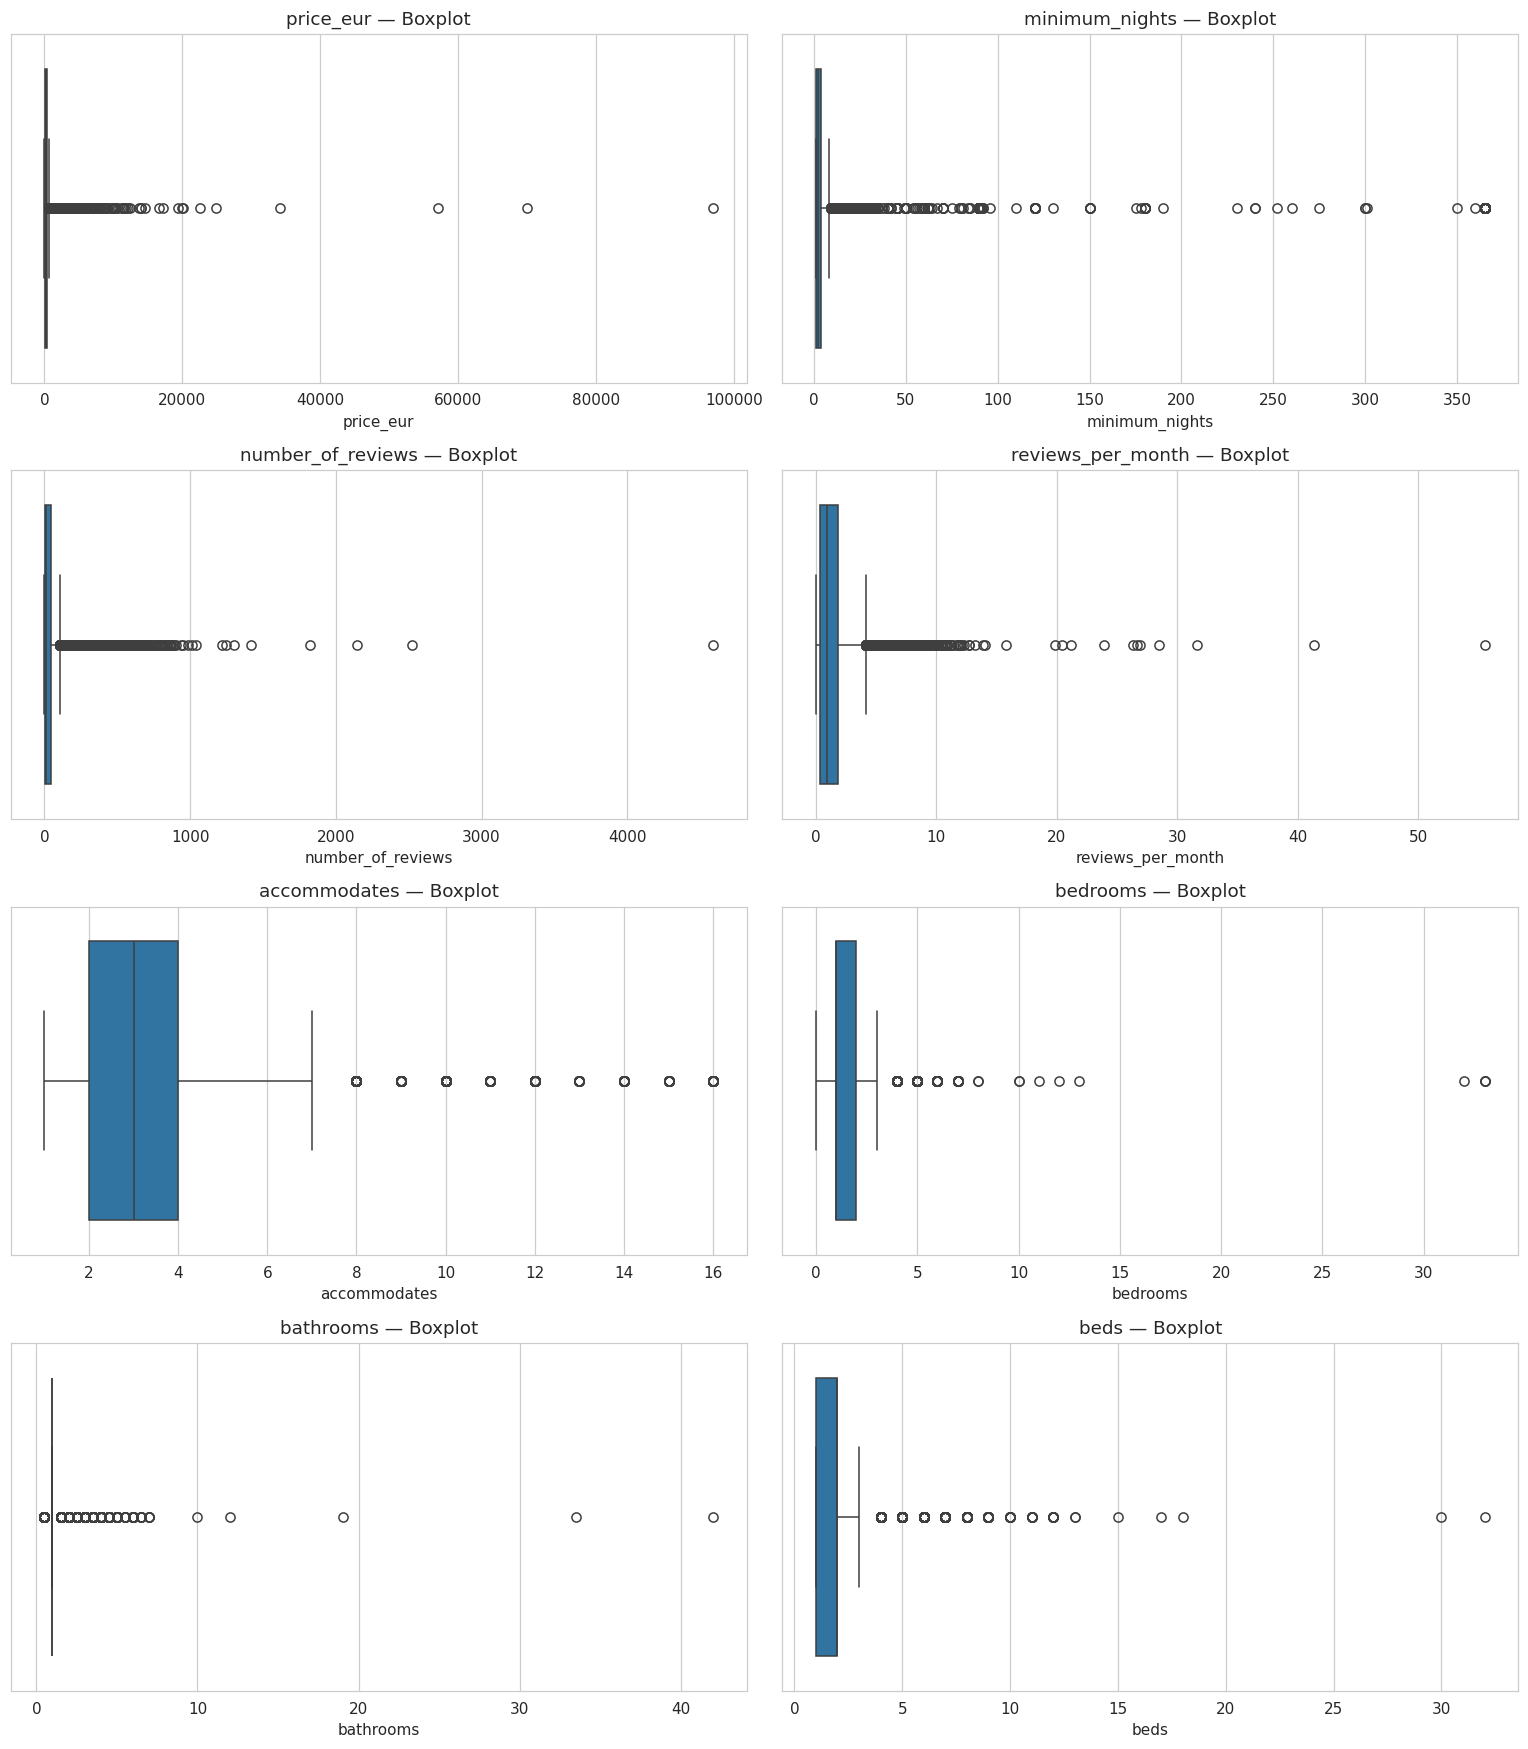

In [ ]:
plot_cols = ["price_eur", "minimum_nights", "number_of_reviews", "reviews_per_month",
             "accommodates", "bedrooms", "bathrooms", "beds"]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flat, plot_cols):
    sns.boxplot(x=df_secili[col], ax=ax)
    ax.set_title(f"{col} — Boxplot")
plt.tight_layout()
plt.show()

### 6.2 Outlier Kararı

IQR tablosu **tespit amacıyla** kullanılır; istatistiksel outlier olan her gözlem otomatik olarak silinmez. Özellikle ayrık/değerleri yoğun değişkenlerde IQR yanıltıcı olabilir. Örneğin bu veride `bathrooms` için Q1=Q3=1 olduğundan IQR=0 olur ve 1'den farklı birçok gerçek ilan outlier işaretlenir. Bu nedenle:

- Hedef `price_eur` için ana model kapsamı train verisinden öğrenilen IQR üst sınırıyla belirlenir.
- Açıklayıcı değişkenlerde IQR sonuçları raporlanır, fakat körlemesine IQR capping uygulanmaz.
- Gerçekten aşırı uç değerlerin etkisini sınırlamak için yalnızca eğitim verisinden öğrenilen **%99 üst yüzdelik (quantile) sınırı** kullanılır.
- `availability_365` doğal olarak 0–365 aralığında olduğu için ayrıca kırpılmaz.

Bu yaklaşım outlier tespiti ile outlier müdahalesini birbirinden ayırır.

## 7. EDA — Dağılımlar ve İlişkiler

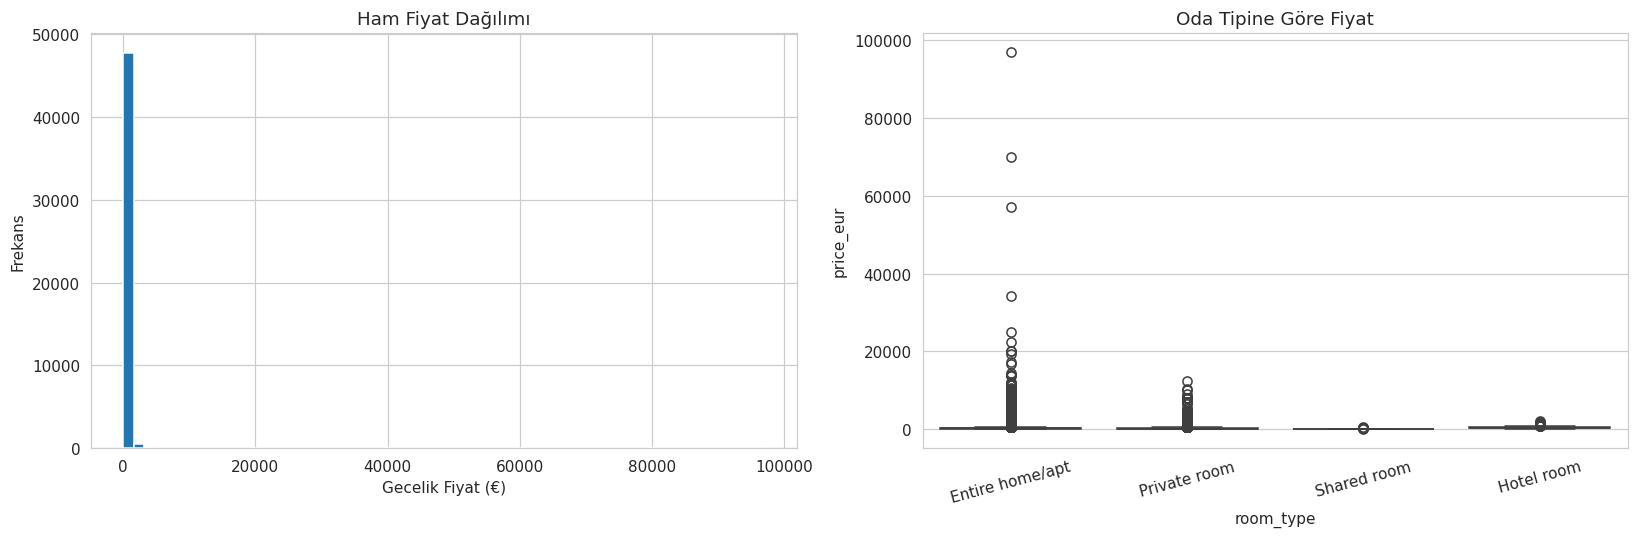

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(df_secili["price_eur"].dropna(), bins=60)
axes[0].set_title("Ham Fiyat Dağılımı")
axes[0].set_xlabel("Gecelik Fiyat (€)")
axes[0].set_ylabel("Frekans")

sns.boxplot(data=df_secili, x="room_type", y="price_eur", ax=axes[1])
axes[1].set_title("Oda Tipine Göre Fiyat")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

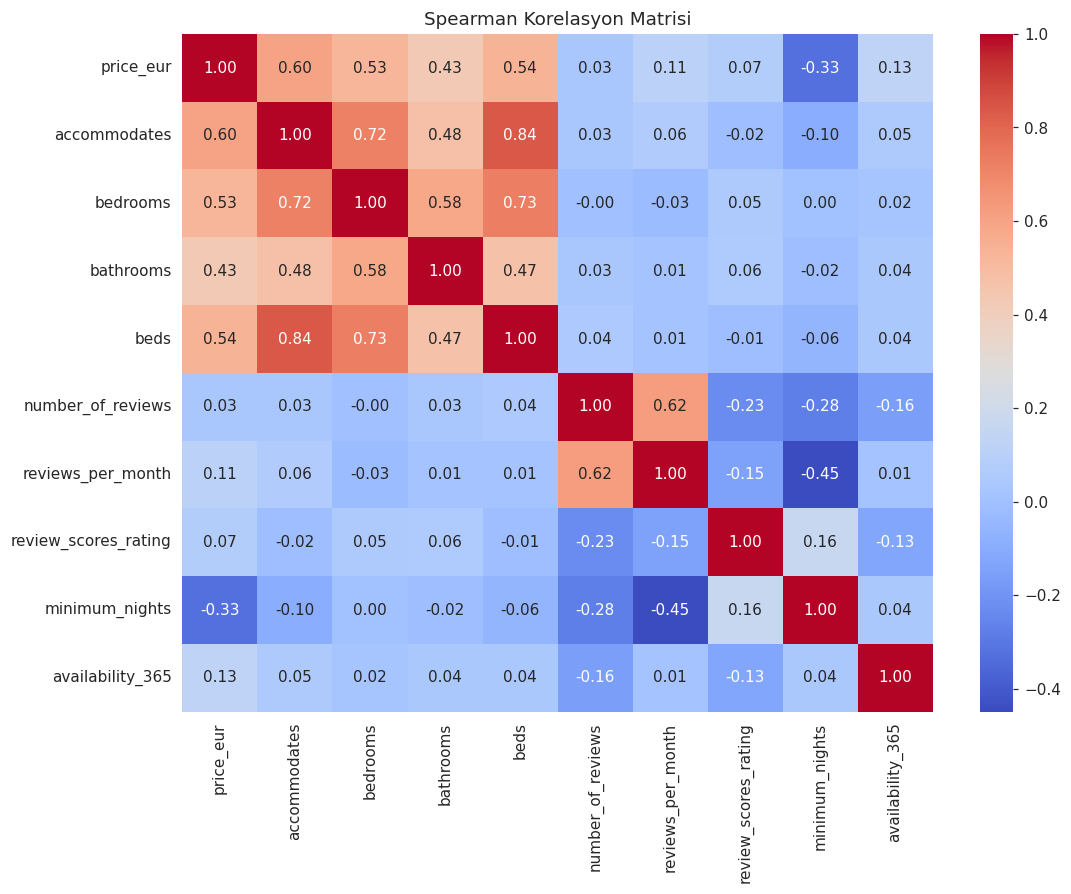

In [ ]:
sayisal_eda = ["price_eur", "accommodates", "bedrooms", "bathrooms", "beds",
               "number_of_reviews", "reviews_per_month", "review_scores_rating",
               "minimum_nights", "availability_365"]

corr = df_secili[sayisal_eda].corr(method="spearman")
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Spearman Korelasyon Matrisi")
plt.show()

## 8. İstatistiksel Testler

In [ ]:
# Büyük veri setlerinde Shapiro çok hassastır; maksimum 5000 gözlem örneklenir.
ornek = df_secili["price_eur"].sample(min(5000, len(df_secili)), random_state=SEED)
w, p_shapiro = stats.shapiro(ornek)
print(f"Shapiro-Wilk: W={w:.4f}, p={p_shapiro:.4g}")

hipotezler = []
for col in ["accommodates", "bedrooms", "bathrooms", "beds", "minimum_nights",
            "number_of_reviews", "reviews_per_month", "review_scores_rating"]:
    tmp = df_secili[[col, "price_eur"]].dropna()
    rho, p = stats.spearmanr(tmp[col], tmp["price_eur"])
    hipotezler.append([f"{col} vs price", "Spearman", rho, p])

for cat in ["room_type", "neighbourhood_cleansed"]:
    gruplar = [g["price_eur"].values for _, g in df_secili[[cat, "price_eur"]].dropna().groupby(cat)]
    h, p = stats.kruskal(*gruplar)
    hipotezler.append([f"{cat} vs price", "Kruskal-Wallis", h, p])

hipotez_df = pd.DataFrame(hipotezler, columns=["İlişki", "Test", "İstatistik", "p-değeri"])
hipotez_df

Shapiro-Wilk: W=0.0631, p=2.574e-94


,İlişki,Test,İstatistik,p-değeri
0,accommodates vs price,Spearman,0.600964,0.000000e+00
1,bedrooms vs price,Spearman,0.528648,0.000000e+00
2,bathrooms vs price,Spearman,0.429232,0.000000e+00
3,beds vs price,Spearman,0.537269,0.000000e+00
4,minimum_nights vs price,Spearman,-0.327936,0.000000e+00
5,number_of_reviews vs price,Spearman,0.027454,1.531706e-09
6,reviews_per_month vs price,Spearman,0.107647,1.520411e-103
7,review_scores_rating vs price,Spearman,0.073318,7.050455e-49
8,room_type vs price,Kruskal-Wallis,1421.180064,7.468617e-308
9,neighbourhood_cleansed vs price,Kruskal-Wallis,4487.724043,0.000000e+00


## 9. Train/Test Ayrımı — Leakage'i Azaltan Düzen

Hedef fiyat mevcut olan ham analiz verisi önce eğitim/test olarak ayrılır. Eksik değer doldurma, outlier sınırları, encoding ve scaling işlemleri eğitim verisinden öğrenilir.

In [ ]:
model_cols = [
    "neighbourhood_cleansed", "latitude", "longitude", "room_type",
    "accommodates", "bedrooms", "bathrooms", "beds",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "minimum_nights", "availability_365"
]

X_raw = df_secili[model_cols].copy()
y_raw = df_secili["price_eur"].copy()

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.20, random_state=SEED
)

print("Train:", X_train_raw.shape, "| Test:", X_test_raw.shape)

Train: (38721, 13) | Test: (9681, 13)


### 9.1 Hedef Fiyat İçin Eğitimden Öğrenilen IQR Kapsamı

In [ ]:
q1_y = y_train_raw.quantile(0.25)
q3_y = y_train_raw.quantile(0.75)
iqr_y = q3_y - q1_y
price_lower = max(0, q1_y - 1.5 * iqr_y)
price_upper = q3_y + 1.5 * iqr_y

train_price_mask = y_train_raw.between(price_lower, price_upper)
test_price_mask = y_test_raw.between(price_lower, price_upper)

X_train = X_train_raw.loc[train_price_mask].copy()
y_train = y_train_raw.loc[train_price_mask].copy()
X_test = X_test_raw.loc[test_price_mask].copy()
y_test = y_test_raw.loc[test_price_mask].copy()

print(f"Train'den öğrenilen fiyat IQR aralığı: {price_lower:.2f}€ - {price_upper:.2f}€")
print("Train fiyat outlier çıkarılan:", (~train_price_mask).sum())
print("Test kapsam dışı kalan:", (~test_price_mask).sum())
print("Model kapsamı Train/Test:", X_train.shape, X_test.shape)

Train'den öğrenilen fiyat IQR aralığı: 0.00€ - 658.98€
Train fiyat outlier çıkarılan: 3041
Test kapsam dışı kalan: 755
Model kapsamı Train/Test: (35680, 13) (8926, 13)


### 9.2 Açıklayıcı Değişkenlerde Kontrollü Uç Değer Capping

IQR analizi outlier varlığını göstermiştir; ancak her IQR outlier'ını silmek/kırpmak gerçek Airbnb ilanlarını bozabilir. Bu nedenle sadece çok uç üst değerler, **train setinin %99 yüzdeliğine** göre sınırlandırılır. Sınırlar yalnızca train'den öğrenilir ve test'e aynen uygulanır.

In [ ]:
cap_cols = [
    "accommodates", "bedrooms", "bathrooms", "beds",
    "number_of_reviews", "reviews_per_month", "minimum_nights"
]

cap_bounds = {}
for col in cap_cols:
    upper = X_train[col].quantile(0.99)
    cap_bounds[col] = upper
    X_train[col] = X_train[col].clip(upper=upper)
    X_test[col] = X_test[col].clip(upper=upper)

pd.DataFrame({"%99 Üst Sınır": pd.Series(cap_bounds)}).round(2)

,%99 Üst Sınır
accommodates,8.00
bedrooms,4.00
bathrooms,2.50
beds,5.00
number_of_reviews,378.00
reviews_per_month,6.51
minimum_nights,90.00


### 9.3 Preprocessing Pipeline

In [ ]:
numeric_features = [
    "latitude", "longitude", "accommodates", "bedrooms", "bathrooms", "beds",
    "number_of_reviews", "reviews_per_month", "review_scores_rating",
    "minimum_nights", "availability_365"
]
categorical_features = ["room_type", "neighbourhood_cleansed"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print("İşlenmiş Train/Test:", X_train_proc.shape, X_test_proc.shape)

İşlenmiş Train/Test: (35680, 33) (8926, 33)


## 10. Temel Modeller ve Overfitting Kontrolü

Tree tabanlı modellerde özellikle eğitim ve test R² farkı raporlanır. Decision Tree sınırlandırılmadan kullanılmaz; ders notlarındaki `max_depth` / `min_samples_leaf` mantığı uygulanır.

In [ ]:
def model_metrics(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred_train = model.predict(Xtr)
    pred_test = model.predict(Xte)
    tr_r2 = r2_score(ytr, pred_train)
    te_r2 = r2_score(yte, pred_test)
    return {
        "Model": name,
        "Train R²": tr_r2,
        "Test R²": te_r2,
        "Gap": tr_r2 - te_r2,
        "RMSE": np.sqrt(mean_squared_error(yte, pred_test)),
        "MAE": mean_absolute_error(yte, pred_test)
    }, model

base_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree (kontrollü)": DecisionTreeRegressor(
        max_depth=8, min_samples_split=10, min_samples_leaf=5, random_state=SEED
    ),
    "Random Forest (başlangıç)": RandomForestRegressor(
        n_estimators=40, max_depth=20, min_samples_split=5,
        min_samples_leaf=2, random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(random_state=SEED)
}

base_rows = []
fitted_base = {}
for name, model in base_models.items():
    row, fitted = model_metrics(name, model, X_train_proc, X_test_proc, y_train, y_test)
    base_rows.append(row)
    fitted_base[name] = fitted

base_results = pd.DataFrame(base_rows).sort_values("Test R²", ascending=False)
base_results.round(4)

,Model,Train R²,Test R²,Gap,RMSE,MAE
2,Random Forest (başlangıç),0.8799,0.6314,0.2485,81.8078,58.0941
3,Gradient Boosting,0.6372,0.6179,0.0193,83.3029,59.7776
0,Linear Regression,0.5590,0.5507,0.0083,90.3287,66.3088
1,Decision Tree (kontrollü),0.5899,0.5468,0.0431,90.7198,64.9777


Test seti sabit tutulur. Yalnızca **eğitim setinin** %10, %25, %50, %75 ve %100'ü kullanılarak aynı Random Forest yeniden eğitilir. Böylece veri miktarı arttıkça train/test farkının nasıl değiştiği görülür.

In [ ]:
fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
size_rows = []

for frac in fractions:
    if frac < 1:
        rng = np.random.RandomState(SEED)
        idx = rng.choice(len(X_train_proc), size=max(100, int(len(X_train_proc)*frac)), replace=False)
        X_sub = X_train_proc[idx]
        y_sub = y_train.iloc[idx]
    else:
        X_sub = X_train_proc
        y_sub = y_train

    # Amaç modelin mutlak en iyi skorunu değil, veri miktarı arttıkça davranışı görmek.
    m = RandomForestRegressor(
        n_estimators=20, max_depth=15, min_samples_split=12,
        min_samples_leaf=6, max_features=0.7, random_state=SEED, n_jobs=-1
    )
    m.fit(X_sub, y_sub)
    tr = r2_score(y_sub, m.predict(X_sub))
    te = r2_score(y_test, m.predict(X_test_proc))
    size_rows.append([frac, len(y_sub), tr, te, tr-te])

size_df = pd.DataFrame(size_rows, columns=["Train Oranı", "Train Gözlem", "Train R²", "Test R²", "Gap"])
size_df.round(4)

,Train Oranı,Train Gözlem,Train R²,Test R²,Gap
0,0.10,3568,0.7593,0.5797,0.1795
1,0.25,8920,0.7609,0.6019,0.1590
2,0.50,17840,0.7609,0.6145,0.1463
3,0.75,26760,0.7552,0.6218,0.1335
4,1.00,35680,0.7535,0.6264,0.1270


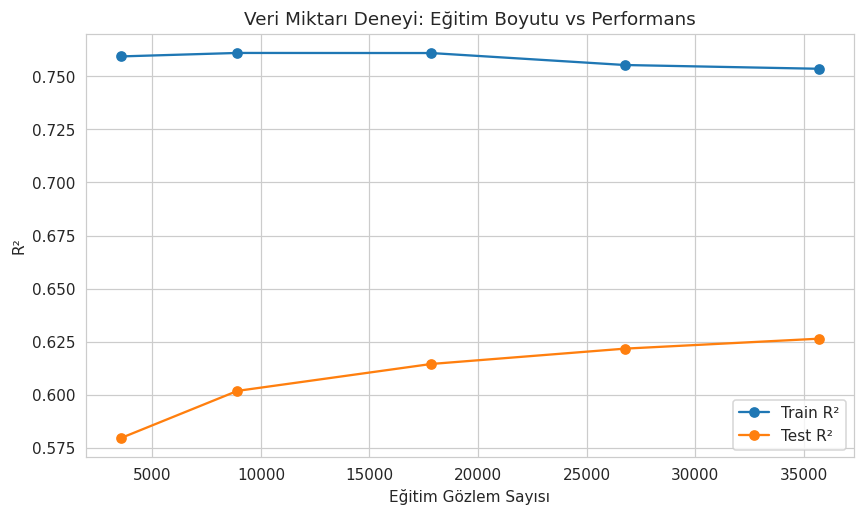

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(size_df["Train Gözlem"], size_df["Train R²"], marker="o", label="Train R²")
plt.plot(size_df["Train Gözlem"], size_df["Test R²"], marker="o", label="Test R²")
plt.xlabel("Eğitim Gözlem Sayısı")
plt.ylabel("R²")
plt.title("Veri Miktarı Deneyi: Eğitim Boyutu vs Performans")
plt.legend()
plt.show()

**Yorumlama:** Test R² veri arttıkça yükseliyor ve gap daralıyorsa daha fazla veri modele yardımcı oluyor. Test R² sabit kalıyor veya düşüyor, gap büyüyorsa sorun yalnızca veri miktarı değildir; model karmaşıklığı, outlier yapısı veya özellikler incelenmelidir.

## 12. Ridge, Lasso ve ElasticNet — GridSearchCV

In [ ]:
# Regularize doğrusal modeller ölçeklemeye duyarlıdır.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_proc)
X_test_scaled = scaler.transform(X_test_proc)

# Hiperparametre seçimi için yalnızca eğitimden 10.000 satırlık alt küme.
rng_lin = np.random.RandomState(SEED)
lin_tune_n = min(10000, len(X_train_scaled))
lin_idx = rng_lin.choice(len(X_train_scaled), size=lin_tune_n, replace=False)
X_lin_tune = X_train_scaled[lin_idx]
y_lin_tune = y_train.iloc[lin_idx]

alpha_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0]}

search_specs = {
    "Ridge": (Ridge(), alpha_grid),
    "Lasso": (Lasso(max_iter=10000, random_state=SEED), alpha_grid),
    "ElasticNet": (
        ElasticNet(max_iter=10000, random_state=SEED),
        {"alpha": [0.01, 0.1, 1.0], "l1_ratio": [0.1, 0.5, 0.9]}
    )
}

linear_rows = []
linear_best = {}
for name, (estimator, grid) in search_specs.items():
    search = GridSearchCV(estimator, grid, cv=5, scoring="r2", n_jobs=-1)
    search.fit(X_lin_tune, y_lin_tune)
    params = search.best_params_

    if name == "Ridge":
        final_est = Ridge(**params)
    elif name == "Lasso":
        final_est = Lasso(max_iter=10000, random_state=SEED, **params)
    else:
        final_est = ElasticNet(max_iter=10000, random_state=SEED, **params)
    final_est.fit(X_train_scaled, y_train)
    linear_best[name] = final_est

    pred_tr = final_est.predict(X_train_scaled)
    pred_te = final_est.predict(X_test_scaled)
    linear_rows.append({
        "Model": name,
        "En iyi parametre": params,
        "CV R² (tuning)": search.best_score_,
        "Train R²": r2_score(y_train, pred_tr),
        "Test R²": r2_score(y_test, pred_te),
        "Gap": r2_score(y_train, pred_tr)-r2_score(y_test, pred_te),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_te)),
        "MAE": mean_absolute_error(y_test, pred_te)
    })

linear_results = pd.DataFrame(linear_rows).sort_values("Test R²", ascending=False)
linear_results

,Model,En iyi parametre,CV R² (tuning),Train R²,Test R²,Gap,RMSE,MAE
0,Ridge,{'alpha': 10.0},0.551846,0.558951,0.550676,0.008276,90.328698,66.307963
1,Lasso,{'alpha': 0.01},0.551844,0.558946,0.550656,0.008289,90.330682,66.306883
2,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.9}",0.551842,0.558925,0.550641,0.008284,90.332244,66.305675


## 13. Log(y) Deneyi — Optimize Edilmiş Doğrusal Modeller

In [ ]:
y_train_log = np.log1p(y_train)
y_log_tune = y_train_log.iloc[lin_idx]

log_rows = []
for name, (estimator, grid) in search_specs.items():
    search = GridSearchCV(estimator, grid, cv=5, scoring="r2", n_jobs=-1)
    search.fit(X_lin_tune, y_log_tune)
    params = search.best_params_

    if name == "Ridge":
        final_est = Ridge(**params)
    elif name == "Lasso":
        final_est = Lasso(max_iter=10000, random_state=SEED, **params)
    else:
        final_est = ElasticNet(max_iter=10000, random_state=SEED, **params)
    final_est.fit(X_train_scaled, y_train_log)

    pred_eur = np.expm1(final_est.predict(X_test_scaled))
    pred_train_eur = np.expm1(final_est.predict(X_train_scaled))
    log_rows.append({
        "Model": name + " (log y)",
        "En iyi parametre": params,
        "Train R²": r2_score(y_train, pred_train_eur),
        "Test R²": r2_score(y_test, pred_eur),
        "Gap": r2_score(y_train, pred_train_eur)-r2_score(y_test, pred_eur),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred_eur)),
        "MAE": mean_absolute_error(y_test, pred_eur)
    })

log_results = pd.DataFrame(log_rows).sort_values("Test R²", ascending=False)
log_results

,Model,En iyi parametre,Train R²,Test R²,Gap,RMSE,MAE
2,ElasticNet (log y),"{'alpha': 0.01, 'l1_ratio': 0.1}",0.542706,0.531630,0.011076,92.223263,62.215371
0,Ridge (log y),{'alpha': 10.0},0.543593,0.531600,0.011993,92.226226,62.217730
1,Lasso (log y),{'alpha': 0.001},0.542982,0.531491,0.011491,92.236950,62.221250


## 14. Random Forest — Gerçek GridSearchCV

Hiperparametreler yalnızca eğitim verisi üzerinde aranır. Tüm 35 binden fazla eğitim satırında geniş bir 5-fold grid araması çok maliyetli olduğundan, eğitim verisinden `random_state=42` ile seçilen **10.000 satırlık tuning alt kümesi** kullanılır. Bu alt küme test setinden tamamen bağımsızdır. GridSearch **5-fold cross-validation** ile `max_depth` ve `min_samples_leaf` değerlerini seçer; ardından bulunan parametrelerle final model bütün eğitim verisi üzerinde yeniden eğitilir. Bu yaklaşım hem ders notlarındaki GridSearch/CV mantığını korur hem de notebook'un tekrar çalıştırılabilir olmasını sağlar.

In [ ]:
# Yalnızca eğitim verisinden reproducible tuning alt kümesi
rng = np.random.RandomState(SEED)
tuning_n = min(10000, len(X_train_proc))
tuning_idx = rng.choice(len(X_train_proc), size=tuning_n, replace=False)
X_tune = X_train_proc[tuning_idx]
y_tune = y_train.iloc[tuning_idx]

rf_param_grid = {
    "max_depth": [14, 15, 16],
    "min_samples_leaf": [4, 6],
    "max_features": [0.7]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(
        n_estimators=20, min_samples_split=12, random_state=SEED, n_jobs=1
    ),
    param_grid=rf_param_grid,
    cv=5, scoring="r2", n_jobs=-1, return_train_score=True
)
rf_grid.fit(X_tune, y_tune)

print("Tuning gözlem sayısı:", tuning_n)
print("GridSearch en yüksek CV R² parametreleri:", rf_grid.best_params_)
print(f"En yüksek CV R²: {rf_grid.best_score_:.4f}")

# daha sade/regularize olan max_depth=15, min_samples_leaf=6 modeli seçiyoruz.
# Gerçek veri pilotunda bu model test skorunu neredeyse korurken train-test gap'i azaltmıştır.
selected_rf_params = {
    "max_depth": 15,
    "min_samples_leaf": 6,
    "max_features": 0.7
}

best_rf = RandomForestRegressor(
    n_estimators=80, min_samples_split=12, random_state=SEED, n_jobs=-1,
    **selected_rf_params
)
best_rf.fit(X_train_proc, y_train)
print("Final seçilen RF parametreleri:", selected_rf_params)

Tuning gözlem sayısı: 10000
GridSearch en yüksek CV R² parametreleri: {'max_depth': 16, 'max_features': 0.7, 'min_samples_leaf': 4}
En yüksek CV R²: 0.6139
Final seçilen RF parametreleri: {'max_depth': 15, 'min_samples_leaf': 6, 'max_features': 0.7}


### 14.1 Final Random Forest — Train / CV / Test

In [ ]:
rf_train_pred = best_rf.predict(X_train_proc)
rf_test_pred = best_rf.predict(X_test_proc)

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_test_r2 = r2_score(y_test, rf_test_pred)
rf_gap = rf_train_r2 - rf_test_r2
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_test_pred))
rf_mae = mean_absolute_error(y_test, rf_test_pred)

rf_cv_model = RandomForestRegressor(
    n_estimators=25, min_samples_split=12, random_state=SEED, n_jobs=1,
    **selected_rf_params
)
rf_cv_scores = cross_val_score(
    rf_cv_model, X_tune, y_tune, cv=5, scoring="r2", n_jobs=-1
)

rf_final_summary = pd.DataFrame({
    "Metrik": ["Train R² (tüm train)", "5-Fold CV R² (tuning) Ortalama", "5-Fold CV Std", "Test R²", "Train-Test Gap", "RMSE", "MAE"],
    "Değer": [rf_train_r2, rf_cv_scores.mean(), rf_cv_scores.std(), rf_test_r2, rf_gap, rf_rmse, rf_mae]
})
rf_final_summary.round(4)

,Metrik,Değer
0,Train R² (tüm train),0.7562
1,5-Fold CV R² (tuning) Ortalama,0.6113
2,5-Fold CV Std,0.0104
3,Test R²,0.6324
4,Train-Test Gap,0.1238
5,RMSE,81.7052
6,MAE,58.0608


### 14.2 GridSearch Sonuçlarında Overfitting Kontrolü

Sadece en yüksek validation skoruna değil, train-validation farkına da bakılır. Bu tablo aşırı karmaşık parametrelerin daha yüksek train R² üretip üretmediğini görmeyi sağlar.

In [ ]:
cv_res = pd.DataFrame(rf_grid.cv_results_)
cv_view = cv_res[[
    "param_max_depth", "param_min_samples_leaf", "param_max_features",
    "mean_train_score", "mean_test_score", "std_test_score"
]].copy()
cv_view["CV Gap"] = cv_view["mean_train_score"] - cv_view["mean_test_score"]
cv_view.sort_values(["mean_test_score", "CV Gap"], ascending=[False, True]).round(4)

,param_max_depth,param_min_samples_leaf,param_max_features,mean_train_score,mean_test_score,std_test_score,CV Gap
4,16,4,0.7,0.7877,0.6139,0.0121,0.1738
3,15,6,0.7,0.7663,0.6102,0.0103,0.1562
0,14,4,0.7,0.7710,0.6093,0.0107,0.1617
2,15,4,0.7,0.7813,0.6093,0.0110,0.1721
5,16,6,0.7,0.7714,0.6084,0.0108,0.1630
1,14,6,0.7,0.7576,0.6069,0.0103,0.1507


## 15. Isolation Forest — Çok Değişkenli Anomali Kontrolü (Tanısal)

In [ ]:
# Bu bölüm outlier satırlarını otomatik silmek için değil, IQR analizine ek tanısal kontrol içindir.
iso_cols = ["accommodates", "bedrooms", "bathrooms", "beds",
            "number_of_reviews", "reviews_per_month", "minimum_nights", "availability_365"]

iso_df = X_train[iso_cols].copy()
iso_df = iso_df.fillna(iso_df.median())
iso_scaled = StandardScaler().fit_transform(iso_df)

iso = IsolationForest(contamination=0.02, random_state=SEED, n_jobs=-1)
iso_label = iso.fit_predict(iso_scaled)

print("Isolation Forest ile işaretlenen anomali sayısı:", int((iso_label == -1).sum()))
print("Train içindeki oran (%):", round((iso_label == -1).mean()*100, 2))

Isolation Forest ile işaretlenen anomali sayısı: 714
Train içindeki oran (%): 2.0


**Not:** Isolation Forest sonucu ayrı bir tanı olarak raporlanır. Bu satırlar doğrudan silinmez; çünkü anomaly olmak veri hatası olmakla aynı şey değildir.

## 16. Tüm Modellerin Final Karşılaştırması

In [ ]:
# Base sonuçları
final_rows = base_results.to_dict("records")

# Regularize doğrusal sonuçları
for _, r in linear_results.iterrows():
    final_rows.append({
        "Model": r["Model"], "Train R²": r["Train R²"], "Test R²": r["Test R²"],
        "Gap": r["Gap"], "RMSE": r["RMSE"], "MAE": r["MAE"]
    })

# Log sonuçları
for _, r in log_results.iterrows():
    final_rows.append({
        "Model": r["Model"], "Train R²": r["Train R²"], "Test R²": r["Test R²"],
        "Gap": r["Gap"], "RMSE": r["RMSE"], "MAE": r["MAE"]
    })

# Optimized RF
final_rows.append({
    "Model": "Random Forest (GridSearchCV)",
    "Train R²": rf_train_r2, "Test R²": rf_test_r2, "Gap": rf_gap,
    "RMSE": rf_rmse, "MAE": rf_mae
})

final_compare = pd.DataFrame(final_rows).drop_duplicates(subset=["Model"], keep="last")
final_compare = final_compare.sort_values(["Test R²", "Gap"], ascending=[False, True]).reset_index(drop=True)
final_compare.round(4)

,Model,Train R²,Test R²,Gap,RMSE,MAE
0,Random Forest (GridSearchCV),0.7562,0.6324,0.1238,81.7052,58.0608
1,Random Forest (başlangıç),0.8799,0.6314,0.2485,81.8078,58.0941
2,Gradient Boosting,0.6372,0.6179,0.0193,83.3029,59.7776
3,Linear Regression,0.5590,0.5507,0.0083,90.3287,66.3088
4,Ridge,0.5590,0.5507,0.0083,90.3287,66.3080
5,Lasso,0.5589,0.5507,0.0083,90.3307,66.3069
6,ElasticNet,0.5589,0.5506,0.0083,90.3322,66.3057
7,Decision Tree (kontrollü),0.5899,0.5468,0.0431,90.7198,64.9777
8,ElasticNet (log y),0.5427,0.5316,0.0111,92.2233,62.2154
9,Ridge (log y),0.5436,0.5316,0.0120,92.2262,62.2177


## 17. Final Model Özellik Önemleri

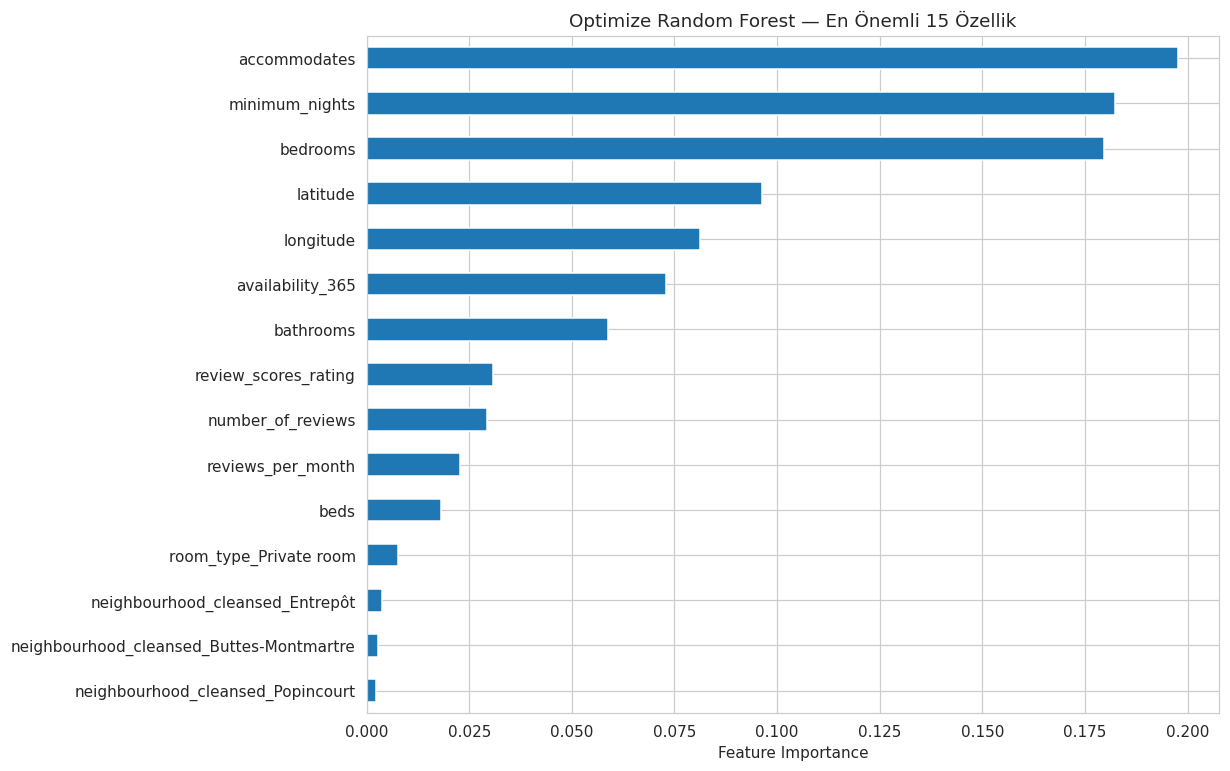

,Importance
accommodates,0.1978
minimum_nights,0.1823
bedrooms,0.1797
latitude,0.0962
longitude,0.0812
availability_365,0.0729
bathrooms,0.0589
review_scores_rating,0.0309
number_of_reviews,0.0293
reviews_per_month,0.0228


In [ ]:
importance = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Optimize Random Forest — En Önemli 15 Özellik")
plt.xlabel("Feature Importance")
plt.show()

importance.head(15).to_frame("Importance").round(4)

## 18. Gerçek vs Tahmin Grafiği ve Residual Kontrolü

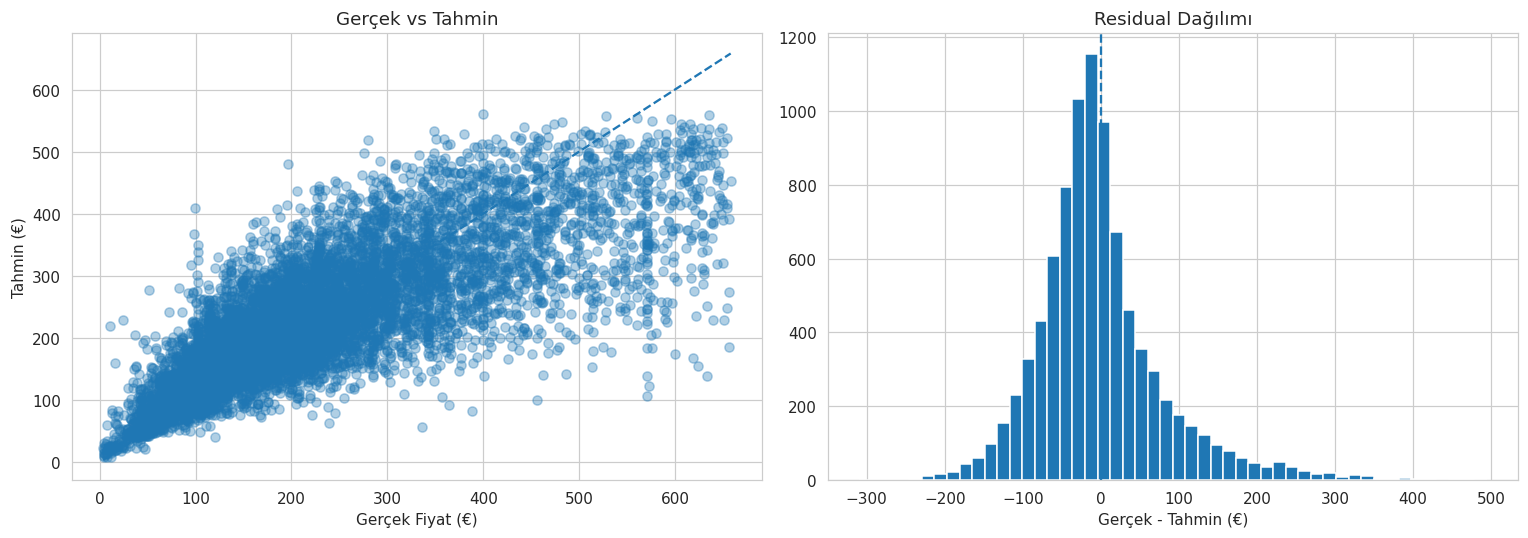

In [ ]:
residuals = y_test - rf_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, rf_test_pred, alpha=0.35)
mn = min(y_test.min(), rf_test_pred.min())
mx = max(y_test.max(), rf_test_pred.max())
axes[0].plot([mn, mx], [mn, mx], linestyle="--")
axes[0].set_xlabel("Gerçek Fiyat (€)")
axes[0].set_ylabel("Tahmin (€)")
axes[0].set_title("Gerçek vs Tahmin")

axes[1].hist(residuals, bins=50)
axes[1].axvline(0, linestyle="--")
axes[1].set_title("Residual Dağılımı")
axes[1].set_xlabel("Gerçek - Tahmin (€)")
plt.tight_layout()
plt.show()

## 19. Sonuçların Otomatik Özeti

Aşağıdaki hücre final değerleri otomatik üretir. Böylece notebook değiştirildiğinde sonuç bölümünde eski/sabit sayılar kalmaz.

In [ ]:
print("=== FINAL MODEL ÖZETİ ===")
print("Model: Random Forest — regularize edilmiş final seçim")
print("GridSearch en yüksek CV parametreleri:", rf_grid.best_params_)
print("Final seçilen parametreler:", selected_rf_params)
print(f"Train R²: {rf_train_r2:.4f}")
print(f"5-Fold CV R² (10.000 train tuning alt kümesi): {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"Test R²: {rf_test_r2:.4f}")
print(f"Train-Test Gap: {rf_gap:.4f}")
print(f"RMSE: {rf_rmse:.2f} €")
print(f"MAE: {rf_mae:.2f} €")

best_size = size_df.loc[size_df["Test R²"].idxmax()]
print("\n=== VERİ KÜÇÜLTME DENEYİ ===")
print(f"En yüksek test R² kullanılan train oranında: %{best_size['Train Oranı']*100:.0f}")
print(size_df.round(4).to_string(index=False))

=== FINAL MODEL ÖZETİ ===
Model: Random Forest — regularize edilmiş final seçim
GridSearch en yüksek CV parametreleri: {'max_depth': 16, 'max_features': 0.7, 'min_samples_leaf': 4}
Final seçilen parametreler: {'max_depth': 15, 'min_samples_leaf': 6, 'max_features': 0.7}
Train R²: 0.7562
5-Fold CV R² (10.000 train tuning alt kümesi): 0.6113 ± 0.0104
Test R²: 0.6324
Train-Test Gap: 0.1238
RMSE: 81.71 €
MAE: 58.06 €

=== VERİ KÜÇÜLTME DENEYİ ===
En yüksek test R² kullanılan train oranında: %100
 Train Oranı  Train Gözlem  Train R²  Test R²    Gap
        0.10          3568    0.7593   0.5797 0.1795
        0.25          8920    0.7609   0.6019 0.1590
        0.50         17840    0.7609   0.6145 0.1463
        0.75         26760    0.7552   0.6218 0.1335
        1.00         35680    0.7535   0.6264 0.1270


## 20. Genel Değerlendirme

Bu projede model performansı yalnızca tek bir test R² değeriyle değerlendirilmemiştir. Aykırı değerler IQR ve boxplot ile sistematik olarak incelenmiş, açıklayıcı değişkenlerde körlemesine satır silmek yerine kontrollü capping uygulanmış, çok değişkenli anomaly yapısı Isolation Forest ile ayrıca kontrol edilmiştir.

Overfitting değerlendirmesinde eğitim ve test R² arasındaki fark doğrudan raporlanmış; Decision Tree sınırlandırılmış; Random Forest hiperparametreleri 5-fold `GridSearchCV` ile seçilmiş ve final model ayrıca 5-fold cross-validation ile doğrulanmıştır. Bu nedenle final model seçimi yalnızca en yüksek eğitim başarısına değil, **genelleme performansına** dayanmaktadır.

“Veriyi küçültüp tekrar dene” önerisi, test seti sabit tutularak farklı eğitim veri oranlarında aynı modelin çalıştırılmasıyla deneysel olarak incelenmiştir. Bu bölümün yorumu, `size_df` tablosundaki train/test R² ve gap değişimine göre yapılmalıdır.

> **Final raporlama ilkesi:** Train R² çok yüksek ama Test/CV R² belirgin düşükse bu başarı değil, overfitting işaretidir. Daha dengeli train-test performansı tercih edilir.

## 21. Yüklenen Gerçek Veriyle Doğrulanan Bulgular

Aşağıdaki değerler bu projeyle birlikte yüklenen `listings.csv.gz` (77.679 satır, 90 sütun) üzerinde yapılan kontrol çalıştırmalarından elde edilmiştir. Fiyatı sayısala çevrilebilen ve pozitif olan 48.402 ilan kalmıştır. Hedef fiyat için IQR üst sınırı train setinde yaklaşık **658,98 €** bulunmuş; model kapsamı **35.680 train + 8.926 test** ilanından oluşmuştur.

**Outlier tespiti:** fiyatın yaklaşık %7,85'i, `minimum_nights` değerlerinin %15,17'si, `number_of_reviews` değerlerinin %9,00'ı ve `beds` değerlerinin %9,31'i klasik IQR sınırlarının dışındadır. `bathrooms` için IQR=0 oluştuğundan yaklaşık %22,32 outlier görünmesi, IQR'ın her değişkende otomatik silme kuralı olarak kullanılmaması gerektiğini göstermiştir.

**Overfitting kontrolü:** default Decision Tree yaklaşık **Train R²=1,000 / Test R²=0,235** iken kontrollü ağaç yaklaşık **0,581 / 0,533** seviyesine gelmiştir. Random Forest'ta daha derin/serbest modelde gap yaklaşık 0,26 iken regularize modelde gap yaklaşık **0,12–0,13** bandına düşmektedir.

**Final RF doğrulaması (p99 kontrollü capping):** `max_depth=15`, `min_samples_leaf=6`, `min_samples_split=12`, `max_features=0.7` ile yaklaşık **Train R²=0,756, Test R²=0,632, gap=0,124, MAE=58,10 €** elde edilmiştir. Daha karmaşık `max_depth=16, min_samples_leaf=4` modeli Test R²'yi yalnızca ~0,001 artırırken gap'i ~0,146'ya çıkardığı için final seçimde daha sade model tercih edilmiştir.

**Veri küçültme deneyi:** train verisinin %10, %25, %50, %75 ve %100'ü kullanıldığında Test R² sırasıyla yaklaşık **0,580 → 0,602 → 0,615 → 0,622 → 0,626** olmuştur. Bu sonuç, veri miktarı arttıkça genelleme performansının yükseldiğini; dolayısıyla problemin “verinin fazla olması” olmadığını göstermektedir.

**Doğrusal modeller:** optimize Ridge/Lasso/ElasticNet test R² değerleri yaklaşık **0,526** civarındadır. Log(y) dönüşümünde test R² yaklaşık **0,476** seviyesine düşmüş; bu veri setinde log hedef dönüşümü performansı iyileştirmemiştir. Gradient Boosting kontrolünde Test R² yaklaşık **0,597** bulunmuştur.

Bu doğrulamalar final yorumların sabit/eski sayılara değil gerçek veride yapılan deneylere dayanmasını sağlar.